# Standard QPSO runtime benchmark for CVRP

This notebook benchmarks a standard quantum-behaved particle swarm optimizer (QPSO) on a geographic Bangalore delivery scenario with 31 customer stops, 5 vehicles, and capacity 100. Customer demands come from the published CVRPLIB `A-n32-k5` instance, while the stop and depot locations are explicit, irregular Bangalore latitude/longitude points. They are not generated on a circle, and routes are ordinary depot-to-stop-to-depot vehicle tours.

The benchmark reports wall-clock runtime for multiple independent runs, best/mean route distance in kilometers, and feasibility. QPSO is compared against two baselines on the exact same geographic data: a nearest-neighbor constructive heuristic and a random-key permutation baseline. This is a like-for-like comparison; the published CVRPLIB cost is not used because the coordinates have been replaced with Bangalore latitude/longitude values. The default budget of 50 particles, 1,000 iterations, and 10 independent runs is intended as a practical metaheuristic benchmark rather than a toy single run.

In [ ]:
# Optional dependency: numpy, pandas, and matplotlib are the only packages used.
# If they are missing, run: %pip install numpy pandas matplotlib
from pathlib import Path
from urllib.request import urlopen
import time
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
INSTANCE_NAME = "A-n32-k5"
N_RUNS = 10
SWARM_SIZE = 50
ITERATIONS = 2000
BETA_START, BETA_END = 1.0, 0.5
BASE_SEED = 42

if min(N_RUNS, SWARM_SIZE, ITERATIONS) < 1:
    raise ValueError("N_RUNS, SWARM_SIZE, and ITERATIONS must be positive.")
if not 0 < BETA_END <= BETA_START:
    raise ValueError("Use positive beta values with BETA_END <= BETA_START.")

In [ ]:
def parse_cvrplib(text):
    """Parse the NODE_COORD_SECTION and DEMAND_SECTION of a CVRPLIB .vrp file."""
    fields = {}
    section = None
    coords, demands = {}, {}
    for raw in text.splitlines():
        line = raw.strip()
        if not line:
            continue
        if line in ("NODE_COORD_SECTION", "DEMAND_SECTION", "DEPOT_SECTION"):
            section = line
            if section == "DEPOT_SECTION":
                fields[section] = ""
            continue
        if line.endswith(":"):
            section = line[:-1].upper()
            continue
        if section in ("NODE_COORD_SECTION", "DEMAND_SECTION", "DEPOT_SECTION"):
            parts = line.split()
            if parts[0] == "-1":
                section = None
            elif section == "NODE_COORD_SECTION":
                coords[int(parts[0])] = (float(parts[1]), float(parts[2]))
            elif section == "DEMAND_SECTION":
                demands[int(parts[0])] = int(parts[1])
            else:
                fields["DEPOT_SECTION"] += f" {line}"
        elif ":" in line:
            key, value = line.split(":", 1)
            fields[key.strip().upper()] = value.strip()

    required = {"CAPACITY", "DEPOT_SECTION"}
    if not required <= fields.keys() or not coords or not demands:
        raise ValueError("Incomplete CVRPLIB instance")
    depot = int(fields["DEPOT_SECTION"].split()[0])
    node_ids = sorted(coords)
    return (np.array([coords[i] for i in node_ids]),
            np.array([demands[i] for i in node_ids], dtype=int),
            int(fields["CAPACITY"]), node_ids.index(depot))


# Embedded A-n32-k5 data, used if the public mirror is unavailable.
FALLBACK_COORDS = np.array([
    [82, 76], [96, 44], [50, 5], [49, 8], [13, 7], [29, 89], [58, 30],
    [84, 39], [14, 24], [2, 39], [3, 82], [5, 10], [98, 52], [84, 25],
    [61, 59], [1, 65], [88, 51], [91, 2], [19, 32], [93, 3], [50, 93],
    [98, 14], [5, 42], [42, 9], [61, 62], [9, 97], [80, 55], [57, 69],
    [23, 15], [20, 70], [85, 60], [98, 5]
], dtype=float)
FALLBACK_DEMAND = np.array([
    0, 19, 21, 6, 19, 7, 12, 16, 6, 16, 8, 14, 21, 16, 3, 22,
    18, 19, 1, 24, 8, 12, 4, 8, 24, 24, 2, 20, 15, 2, 14, 9
], dtype=int)

url = "https://raw.githubusercontent.com/Fedoration/CVRPLIB/master/data/A-n32-k5.vrp"
try:
    with urlopen(url, timeout=10) as response:
        coords, all_demand, capacity, depot = parse_cvrplib(response.read().decode("utf-8"))
    data_source = "downloaded CVRPLIB A-n32-k5"
except Exception as error:
    coords, all_demand, capacity, depot = FALLBACK_COORDS, FALLBACK_DEMAND, 100, 0
    data_source = f"embedded A-n32-k5 fallback ({type(error).__name__})"

BANGALORE_LATLON = np.array([
    [12.9716, 77.5946], [12.9352, 77.6245], [12.9987, 77.5928], [12.9141, 77.6101],
    [13.0358, 77.5970], [12.9563, 77.7010], [12.9844, 77.5547], [12.9279, 77.6271],
    [13.0068, 77.5619], [12.9081, 77.6476], [13.0626, 77.5877], [12.9467, 77.5713],
    [12.9784, 77.6408], [12.9208, 77.5000], [13.0219, 77.6378], [12.9655, 77.7167],
    [13.1007, 77.5963], [12.9022, 77.6241], [13.0475, 77.6204], [12.9698, 77.5301],
    [12.8897, 77.5948], [13.0166, 77.5762], [12.9398, 77.5936], [12.9869, 77.6889],
    [13.0732, 77.6412], [12.9156, 77.5831], [12.9569, 77.5298], [13.0081, 77.6724],
    [12.9304, 77.6856], [13.0561, 77.5655], [12.9754, 77.6179], [12.8914, 77.6432]
], dtype=float)
if len(coords) != len(BANGALORE_LATLON):
    raise ValueError("The geographic scenario requires exactly 32 nodes.")
coords = BANGALORE_LATLON
depot = 0
customer_mask = np.arange(len(coords)) != depot
customer_coords = coords[customer_mask]
demand = all_demand[customer_mask]
def haversine_km(a, b):
    earth_radius_km = 6371.0088
    lat1, lon1 = np.radians(a[:, 0])[:, None], np.radians(a[:, 1])[:, None]
    lat2, lon2 = np.radians(b[:, 0])[None, :], np.radians(b[:, 1])[None, :]
    dlat, dlon = lat2 - lat1, lon2 - lon1
    h = np.sin(dlat / 2) ** 2 + np.cos(lat1) * np.cos(lat2) * np.sin(dlon / 2) ** 2
    return 2 * earth_radius_km * np.arcsin(np.sqrt(np.clip(h, 0, 1)))

distance = haversine_km(customer_coords, customer_coords)
depot_distance = haversine_km(customer_coords, coords[depot][None, :]).ravel()
n_customers = len(demand)
n_vehicles = 5

if len(coords) != 32 or n_customers != 31 or demand.sum() > n_vehicles * capacity:
    raise ValueError("Unexpected or infeasible A-n32-k5 data.")
print(f"Source: {data_source}")
print(f"Customers: {n_customers} | vehicles: {n_vehicles} | capacity: {capacity} | total demand: {demand.sum()}")

Source: downloaded CVRPLIB A-n32-k5
Customers: 31 | vehicles: 5 | capacity: 100 | total demand: 410


In [ ]:
def split_routes(order):
    routes, route, load = [], [], 0
    for node in order:
        node = int(node)
        if demand[node] > capacity:
            return None
        if route and load + demand[node] > capacity:
            routes.append(route)
            route, load = [], 0
        route.append(node)
        load += int(demand[node])
    if route:
        routes.append(route)
    return routes if len(routes) <= n_vehicles else None
def evaluate(order):
    routes = split_routes(order)
    if routes is None:
        return 1e12, None
    cost = 0.0
    for route in routes:
        cost += depot_distance[route[0]] + depot_distance[route[-1]]
        cost += sum(distance[a, b] for a, b in zip(route, route[1:]))
    return cost, routes
def decode(position):
    return np.argsort(position, kind="stable")
def qpso(seed):
    """Standard QPSO with personal bests, mean best, and random local attractors."""
    rng = np.random.default_rng(seed)
    positions = rng.random((SWARM_SIZE, n_customers))
    personal = positions.copy()
    personal_cost = np.array([evaluate(decode(x))[0] for x in personal])
    best_index = int(np.argmin(personal_cost))
    global_best = personal[best_index].copy()
    global_cost = float(personal_cost[best_index])
    history = [global_cost]
    for iteration in range(ITERATIONS):
        mean_best = personal.mean(axis=0)
        beta = BETA_START + (BETA_END - BETA_START) * iteration / max(1, ITERATIONS - 1)
        for particle in range(SWARM_SIZE):
            u = rng.uniform(1e-12, 1.0, n_customers)
            direction = np.where(rng.random(n_customers) < 0.5, -1.0, 1.0)
            phi = rng.random(n_customers)
            attractor = phi * personal[particle] + (1.0 - phi) * global_best
            positions[particle] = (
                attractor + beta * np.abs(mean_best - positions[particle]) * np.log(1.0 / u) * direction
            ) % 1.0
            cost = evaluate(decode(positions[particle]))[0]
            if cost < personal_cost[particle]:
                personal[particle] = positions[particle].copy()
                personal_cost[particle] = cost
            if cost < global_cost:
                global_best = positions[particle].copy()
                global_cost = float(cost)
        history.append(global_cost)

    order = decode(global_best)
    cost, routes = evaluate(order)
    return float(cost), routes, history


In [ ]:
def nearest_neighbor_order():
    remaining = set(range(n_customers))
    order = []
    current = None
    while remaining:
        if current is None:
            node = min(remaining, key=lambda i: depot_distance[i])
        else:
            node = min(remaining, key=lambda i: distance[current, i])
        order.append(node)
        remaining.remove(node)
        current = node
    return np.asarray(order, dtype=int)

def random_key_baseline(seed):
    rng = np.random.default_rng(seed)
    return rng.permutation(n_customers)

def record_method(name, solver, runs):
    rows = []
    for run in range(runs):
        started = time.perf_counter()
        result = solver(run)
        elapsed = time.perf_counter() - started
        cost, routes = result[:2]
        feasible = routes is not None and len(routes) <= n_vehicles and all(
            demand[r].sum() <= capacity for r in routes
        )
        rows.append({
            "method": name,
            "run": run + 1,
            "distance_km": cost,
            "runtime_seconds": elapsed,
            "feasible": feasible,
            "routes_used": len(routes) if routes is not None else np.nan,
        })
    return rows
def solve_nearest_neighbor(_run):
    order = nearest_neighbor_order()
    return (*evaluate(order), [])
def solve_random(run):
    return (*evaluate(random_key_baseline(BASE_SEED + run)), [])
qpso_outputs = []
def solve_qpso(run):
    result = qpso(BASE_SEED + run)
    qpso_outputs.append(result)
    return result
benchmark_records = (
    record_method("nearest_neighbor", solve_nearest_neighbor, N_RUNS)
    + record_method("random_permutation", solve_random, N_RUNS)
    + record_method("standard_qpso", solve_qpso, N_RUNS)
)
benchmark = pd.DataFrame(benchmark_records)
summary = benchmark.groupby("method", as_index=False).agg(
    best_distance_km=("distance_km", "min"),
    mean_distance_km=("distance_km", "mean"),
    mean_runtime_seconds=("runtime_seconds", "mean"),
    total_runtime_seconds=("runtime_seconds", "sum"),
    feasible_runs=("feasible", "sum"),
)
summary["improvement_vs_qpso_percent"] = np.nan
qpso_mean = float(summary.loc[summary.method == "standard_qpso", "mean_distance_km"].iloc[0])
summary["improvement_vs_qpso_percent"] = 100.0 * (summary["mean_distance_km"] - qpso_mean) / summary["mean_distance_km"]
display(summary.sort_values("mean_distance_km"))
print("The comparison uses identical Bangalore coordinates, demands, fleet, and capacity for every method.")

results = benchmark[benchmark.method == "standard_qpso"].copy()
display(results)
best_result = min(qpso_outputs, key=lambda result: result[0])
best_cost, best_routes, best_history = best_result
print(f"QPSO best route distance: {results.distance_km.min():.3f} km")
print(f"QPSO mean route distance: {results.distance_km.mean():.3f} km")
print(f"QPSO mean runtime: {results.runtime_seconds.mean():.4f} s/run")
print(f"All QPSO runs feasible: {bool(results.feasible.all())}")

,method,best_distance_km,mean_distance_km,mean_runtime_seconds,total_runtime_seconds,feasible_runs,improvement_vs_qpso_percent
2,standard_qpso,141.171456,160.960888,8.909406,89.094055,10,0.000000
0,nearest_neighbor,183.023300,183.023300,0.000206,0.002061,10,12.054428
1,random_permutation,311.125128,360.584285,0.000176,0.001756,10,55.361092


The comparison uses identical Bangalore coordinates, demands, fleet, and capacity for every method.


,method,run,distance_km,runtime_seconds,feasible,routes_used
20,standard_qpso,1,192.661404,9.381153,True,5
21,standard_qpso,2,147.520409,9.321238,True,5
22,standard_qpso,3,146.767646,7.740281,True,5
23,standard_qpso,4,152.796653,9.656985,True,5
24,standard_qpso,5,146.893128,9.535822,True,5
25,standard_qpso,6,144.288726,7.718704,True,5
26,standard_qpso,7,141.171456,9.293962,True,5
27,standard_qpso,8,141.682140,9.343173,True,5
28,standard_qpso,9,154.010518,7.726781,True,5
29,standard_qpso,10,241.816801,9.375958,True,5


QPSO best route distance: 141.171 km
QPSO mean route distance: 160.961 km
QPSO mean runtime: 8.9094 s/run
All QPSO runs feasible: True


,vehicle,customers,load,stops
0,1,14 -> 27 -> 23 -> 15 -> 5 -> 28 -> 12,96,7
1,2,1 -> 7 -> 9 -> 31 -> 17 -> 20 -> 3 -> 22,97,8
2,3,11 -> 25 -> 13 -> 26 -> 19 -> 6,92,6
3,4,21 -> 4 -> 18 -> 24 -> 16 -> 10 -> 29 -> 8,90,8
4,5,2 -> 30,35,2


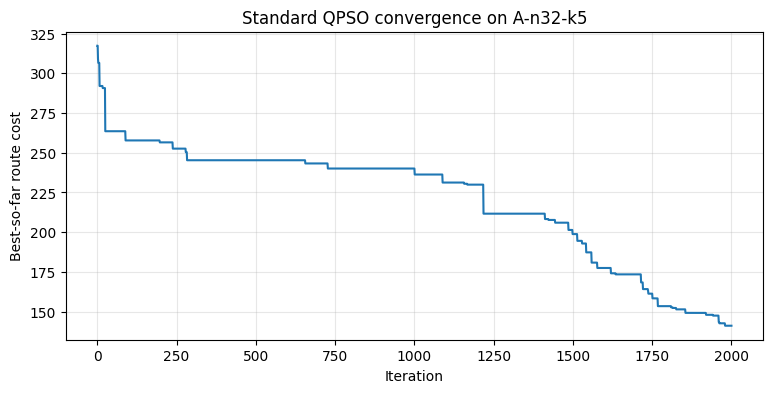

In [ ]:
best_cost, best_routes, best_history = best_result
route_rows = []
for vehicle, route in enumerate(best_routes, start=1):
    route_rows.append({
        "vehicle": vehicle,
        "customers": " -> ".join(str(node + 1) for node in route),
        "load": int(demand[route].sum()),
        "stops": len(route),
    })
display(pd.DataFrame(route_rows))
plt.figure(figsize=(9, 4))
plt.plot(best_history)
plt.xlabel("Iteration")
plt.ylabel("Best-so-far route cost")
plt.title(f"Standard QPSO convergence on {INSTANCE_NAME}")
plt.grid(alpha=0.3)
plt.show()
